# Introducción
Este Notebook desarrolla el analisis de exploración de datos:
Comprensión_eda.ipynb: Análisis experimental y exploratorio de datos. En este notebook se debe realizar el análisis exploratorio de la base de datos, teniendo en cuenta:
* Exploración inicial de datos 
- Descripción general de los datos. Caracterización de los datos: categóricos, numéricos, ordinales, nominales, dicotómicos, politómicos. Revisión de nulos. 
- Unificar la forma como se representan los valores Nulos. 
- Eliminación de variables irrelevantes. 
- Convertir los datos en su tipo correcto (numéricos, categóricos, booleanos, fechas, etc) y corrección de los datos si es necesario, para cada columna tenga un tipo de dato uniforme.

*Exploración de datos y descripción (EDA) 
- Análisis univariable. Se recomienda hacer un describe() una vez se hayan ajustado los tipos de datos. Se recomienda para las variables numéricas: histograma para distribución, boxplot, tablas pivote. Para las variables categóricas: countplot, tablas pivote, value_counts() Descripción estadística (dependiendo del tipo de dato): por ejemplo para los numéricos: tendencia Central (media, mediana, moda, max, min, etc), medidas de dispersión (Rango, IQR, cuartiles, varianza, desviación estándar, skewness y kurtosis). Tipo de distribución (gaussiana, uniforme, logarítmica, etc.) 
- Análisis bivariable. Se recomienda generar gráficos y tablas con respecto a la variable objetivo y comentar. 
- Análisis multivariable. Revisar relaciones entre variables. Se puede incluir un pairplot(), tablas cruzadas, matriz de correlación, gráficos de dispersión entre variables numéricas, gráficos utilizando el parámetro hue para las variables categóricas. El análisis debe contener: compresión detallada de las características y el esquema de datos. Muchos comentarios, interpretaciones, análisis de lo que se encuentra, analice los datos para crear las reglas de validación de los datos que serán usadas en otra etapa del proyecto. Identificar las transformaciones que tal vez se puedan aplicar.  Identificar atributos adicionales (derivados, calculados) que pueden ser útiles.

# 1. INICIACIÓN ANALISIS DE EXPLORACIÓN DE DATOS
-Exploración inicial de datos
-Exploración de datos y descripción (EDA) 
* Análisis univariable. 
*Análisis bivariable.
*Análisis multivariable.


In [1]:
print ('hola mundo')

hola mundo


In [2]:
#Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
print ("librerías importadas correctamente")
print("=" * 100) 

librerías importadas correctamente


In [3]:
#cargar datos
df = pd.read_excel('../../Base_de_datos.xlsx')
print ("datos cargados correctamente")
print("=" * 100) 

datos cargados correctamente


In [4]:
# Identificación del target: En este caso, el target es la variable 'pago a tiempo' que indica si el cliente pagó a tiempo o no.
print("Target identificado: 'pago a tiempo'")

Target identificado: 'pago a tiempo'


# 2. Análisis del target


Distribución de Pago a Tiempo (en porcentaje):
Pago_atiempo
1    95.252253
0     4.747747
Name: proportion, dtype: float64


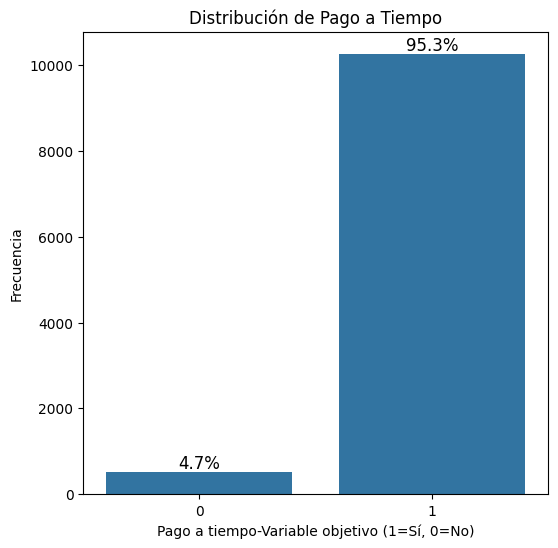

In [5]:
#validar distribución de la variable objetivo si o no paga a tiempo en porcentaje
pago_atiempo_counts = df['Pago_atiempo'].value_counts(normalize=True) * 100
print("\nDistribución de Pago a Tiempo (en porcentaje):")
print(pago_atiempo_counts)
plt.figure(figsize=(6,6))
ax = sns.countplot(x='Pago_atiempo', data=df)
# Agregar porcentajes en las barras
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height() + 5  # Ajustar posición
    ax.annotate(percentage, (x, y), ha='center', va='bottom', size=12)
#titulos y etiquetas con porcentaje
plt.title('Distribución de Pago a Tiempo')
plt.xlabel('Pago a tiempo-Variable objetivo (1=Sí, 0=No)')
plt.ylabel('Frecuencia')
plt.show()

## Se observa que la variable objetivo está desbalanceada , con una mayoría de clientes que pagan a tiempo (1) con 95.3% y una minoría que no paga a tiempo (0) del 4.7% (Altamente desbalanceado). Esto es importante tenerlo en cuenta para el modelado, ya que podría ser necesario aplicar técnicas de balanceo de clases para mejorar el rendimiento del modelo, es decir criterios como:ROC-AUC,Recall,PR-AUC y no solamente Accuracy

# 3. Calidad de los Datos

In [6]:
# valores nulos importantes
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("=" * 100) 


Valores nulos por columna:
tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64


In [7]:
# valores nulos importantes
#mostrar solo las columnas con valores nulos y en porcentajes
print("\nPorcentaje de valores nulos por columna:")
nulos_porcentaje = df.isnull().mean() * 100
print(nulos_porcentaje[nulos_porcentaje > 0 ])
print("=" * 100) 


Porcentaje de valores nulos por columna:
puntaje_datacredito               0.055747
saldo_mora                        1.449410
saldo_total                       1.449410
saldo_principal                   3.762891
saldo_mora_codeudor               5.481743
promedio_ingresos_datacredito    27.222893
tendencia_ingresos               27.241475
dtype: float64


In [8]:
print("\nProblemas detectados:")
print("- La variable objetivo 'Pago_atiempo' está desbalanceada, con una mayoría de clientes pagando a tiempo. Esto podría afectar el rendimiento del modelo.")
print("- Hay varias columnas con valores nulos, lo que podría requerir técnicas de imputación o eliminación de filas/columnas dependiendo del porcentaje de nulos y su importancia.")   
print("- Edad cliente tiene valores maximos de 123 años, lo cual es poco probable y podría indicar errores en los datos.")
print("- salario cliente con outliers extremos, con un valores máximos de 22.000.000.000 (22 mil millones mensuales), lo cual es poco probable y podría indicar errores en los datos.")
print("- La variable Puntaje con numeros negativos que no deberian existir.")
print("- La variable tendencia ingresos con valores extremos que no parecen realistas, lo que podría indicar limpieza o agrupación a realizar.")



Problemas detectados:
- La variable objetivo 'Pago_atiempo' está desbalanceada, con una mayoría de clientes pagando a tiempo. Esto podría afectar el rendimiento del modelo.
- Hay varias columnas con valores nulos, lo que podría requerir técnicas de imputación o eliminación de filas/columnas dependiendo del porcentaje de nulos y su importancia.
- Edad cliente tiene valores maximos de 123 años, lo cual es poco probable y podría indicar errores en los datos.
- salario cliente con outliers extremos, con un valores máximos de 22.000.000.000 (22 mil millones mensuales), lo cual es poco probable y podría indicar errores en los datos.
- La variable Puntaje con numeros negativos que no deberian existir.
- La variable tendencia ingresos con valores extremos que no parecen realistas, lo que podría indicar limpieza o agrupación a realizar.


# 5. VARIABLES IMPORTANTES PARA PREDECIR EL PAGO A TIEMPO

relevantes para riesgo según:
**Financiero**
capital_prestado
cuota_pactada
saldo_total
saldo_mora
**Cliente**
edad_cliente
tipo_laboral
salario_cliente
**Historial crediticio**
puntaje
puntaje_datacredito
cant_creditosvigentes
huella_consulta
**Y Categoricas**
Tipo Laboral: Empleado e Independiente

# 6. ANÁLISIS UNIVARIABLE 
se interpretan variables numericas y categoricas

In [9]:
df.describe()


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,...,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121664,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,...,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,...,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,...,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,...,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,...,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,...,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


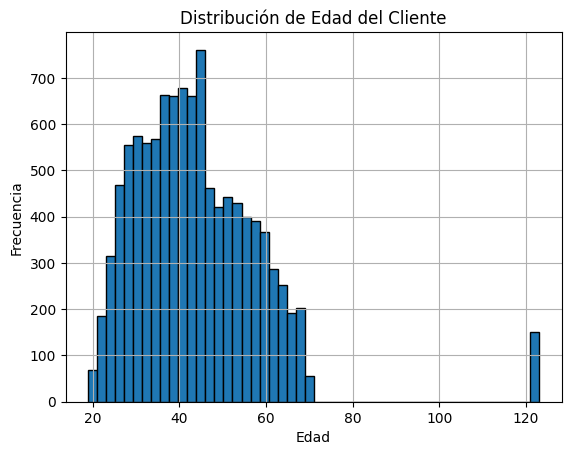

In [10]:
# histograma de la edad del cliente
df['edad_cliente'].hist(bins=50, edgecolor='black')
plt.title('Distribución de Edad del Cliente')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

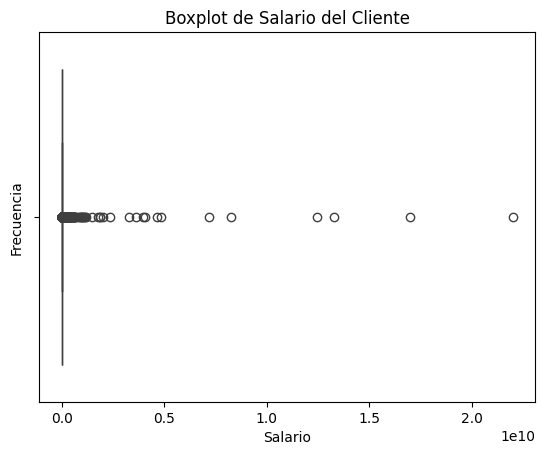

In [11]:
#boxplot del salario del cliente
sns.boxplot(x=df['salario_cliente']) 
plt.title('Boxplot de Salario del Cliente')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()



La variable salario_cliente presenta una alta dispersión con valores extremos, lo que sugiere la presencia de outliers.

In [17]:
df['tipo_laboral'].value_counts()

tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

Pago_atiempo,0,1
tipo_laboral,,
Empleado,0.042938,0.957062
Independiente,0.055126,0.944874


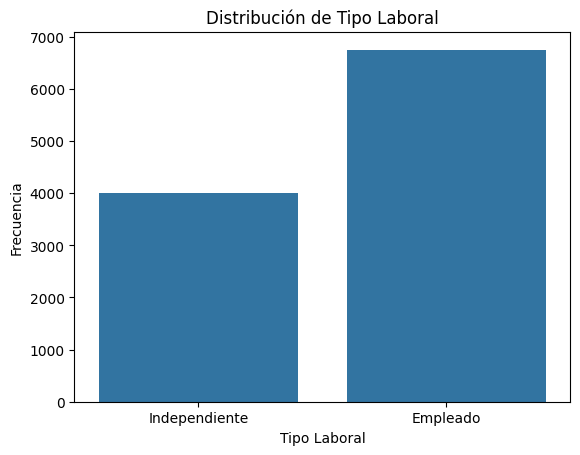

In [26]:
#grafico de barras labora independente o como empleado
sns.countplot(x='tipo_laboral', data=df) 
plt.title('Distribución de Tipo Laboral')
plt.xlabel('Tipo Laboral')
plt.ylabel('Frecuencia')
plt.show()



# 7. ANÁLISIS BIVARIABLE
Se interpretan variables con el target y observan relaciones claves

In [28]:
#tabla cruzada entre tipo laboral y pago a tiempo
pd.crosstab(df['tipo_laboral'], df['Pago_atiempo'], normalize='index') 

Pago_atiempo,0,1
tipo_laboral,,
Empleado,0.042938,0.957062
Independiente,0.055126,0.944874


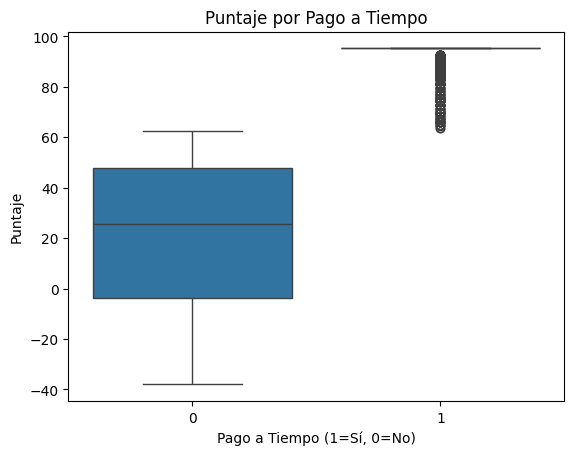

Los clientes que pagan a tiempo tienden a tener puntajes más altos, lo que sugiere una posible relación entre el puntaje y la probabilidad de pagar a tiempo.


In [33]:
sns.boxplot(x='Pago_atiempo', y='puntaje', data=df) 
plt.title('Puntaje por Pago a Tiempo')
plt.xlabel('Pago a Tiempo (1=Sí, 0=No)')
plt.ylabel('Puntaje')
plt.show()
print("Los clientes que pagan a tiempo tienden a tener puntajes más altos, lo que sugiere una posible relación entre el puntaje y la probabilidad de pagar a tiempo.")  

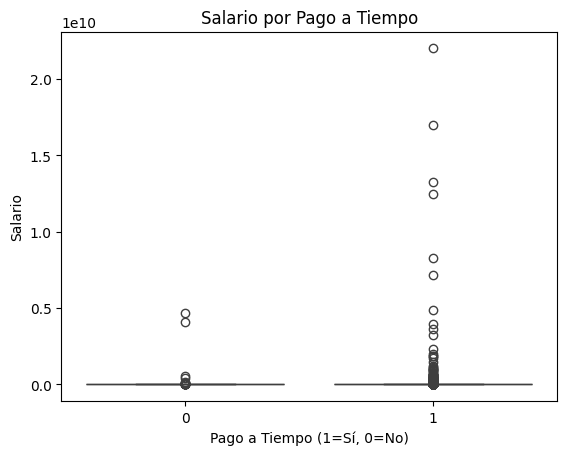

 Los clientes que pagan a tiempo tienden a tener salarios más altos, lo que sugiere una posible relación entre el salario y la probabilidad de pagar a tiempo.


In [34]:
# grafico de boxplot de salario vs pago a tiempo
sns.boxplot(x='Pago_atiempo', y='salario_cliente', data=df)
plt.title('Salario por Pago a Tiempo')
plt.xlabel('Pago a Tiempo (1=Sí, 0=No)')
plt.ylabel('Salario')
plt.show()
print(" Los clientes que pagan a tiempo tienden a tener salarios más altos, lo que sugiere una posible relación entre el salario y la probabilidad de pagar a tiempo.") 


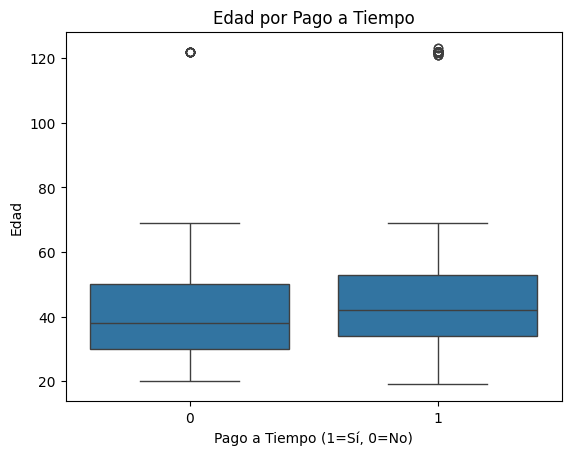

In [ ]:
# grafico edad vs pago a tiempo
sns.boxplot(x='Pago_atiempo', y='edad_cliente', data=df)
plt.title('Edad por Pago a Tiempo')
plt.xlabel('Pago a Tiempo (1=Sí, 0=No)')
plt.ylabel('Edad')
plt.show()
print(" No se observa una diferencia clara en la edad entre los clientes que pagan a tiempo y los que no, lo que sugiere que la edad podría no ser un factor determinante para el pago a tiempo.")


# 8. ANÁLISIS MULTIVARIABLE
Se interpretan correlaciónes e Interacciónes entre variables con la variable obejtivo

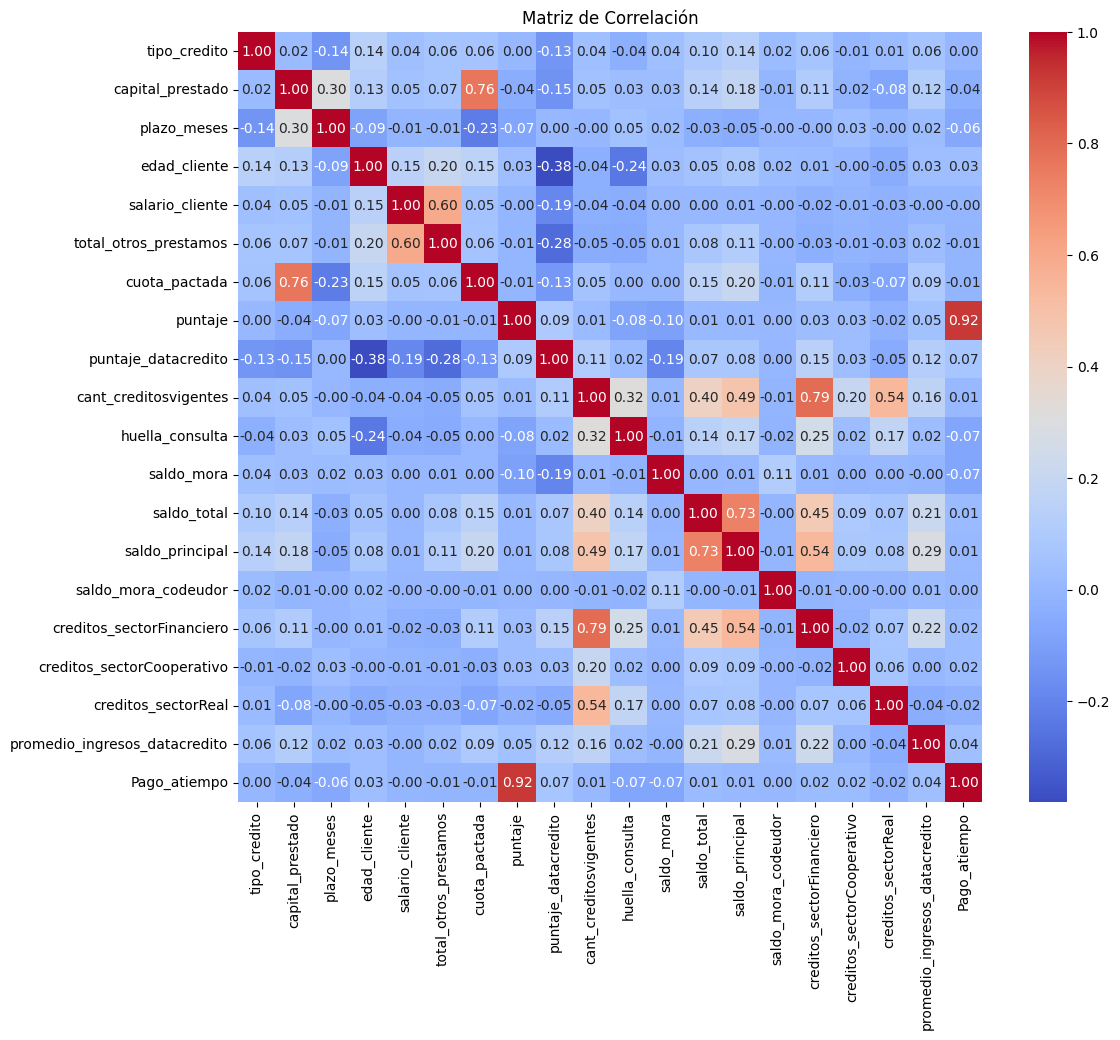

In [32]:
#correlación entre variables numéricas
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

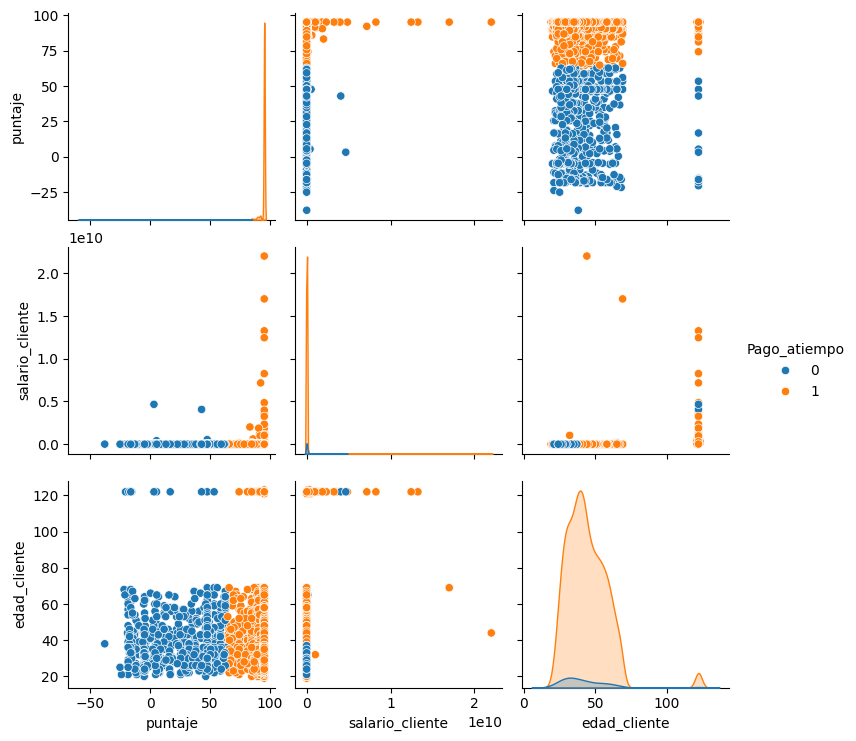

In [ ]:
#PAIRPLOT
sns.pairplot(df[["Pago_atiempo", "puntaje", "salario_cliente", "edad_cliente"]], hue="Pago_atiempo")
plt.show()
print("El pairplot muestra que los clientes que pagar a tiempo tienden a tener puntajes y salarios más altos, mientras que no se observa una diferencia clara en la edad, lo que refuerza las observaciones anteriores sobre la relación entre estas variables y el pago a tiempo.")

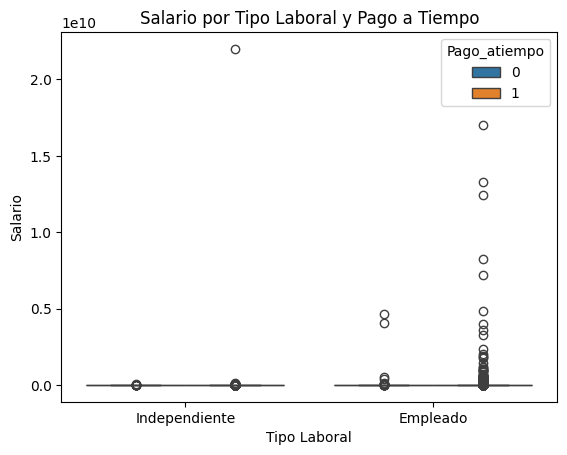

In [37]:
sns.boxplot(x='tipo_laboral', y='salario_cliente', hue='Pago_atiempo', data=df)
plt.title('Salario por Tipo Laboral y Pago a Tiempo')
plt.xlabel('Tipo Laboral')
plt.ylabel('Salario')
plt.show()

## Conclusiones del EDA

- El dataset presenta un fuerte desbalance en la variable objetivo (Pago_atiempo), lo que requiere el uso de métricas robustas como ROC-AUC y Recall.
- Se identifican valores atípicos en variables clave como edad, salario y puntaje, los cuales deberán ser tratados en la etapa de feature engineering.
- Variables relacionadas con historial crediticio (puntaje, número de créditos, saldo) muestran alto potencial predictivo.
- Las variables provenientes de Datacrédito presentan valores faltantes significativos, lo cual sugiere la necesidad de estrategias de imputación.
- La variable tipo_laboral podría tener impacto en el comportamiento de pago.